In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [6]:
os.makedirs(
    "../results/week4_results",
    exist_ok=True
)

print("Folder Ready")

Folder Ready


In [8]:
train_df = pd.read_csv(
    "../Outputs/Notebook_03/train_embeddings.csv"
)

print(train_df.shape)

(14446, 513)


In [9]:
train_df.columns

Index(['Image', 'F0', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8',
       ...
       'F502', 'F503', 'F504', 'F505', 'F506', 'F507', 'F508', 'F509', 'F510',
       'F511'],
      dtype='str', length=513)

In [10]:
train_df = train_df.drop(
    columns=["Image"]
)

print(train_df.shape)

(14446, 512)


In [11]:
pca = PCA(
    n_components=128
)

compressed_embeddings = pca.fit_transform(
    train_df
)

print(
    compressed_embeddings.shape
)

(14446, 128)


In [12]:
variance_retained = np.sum(
    pca.explained_variance_ratio_
)

print(
    "Variance Retained:",
    round(
        variance_retained*100,
        2
    ),
    "%"
)

Variance Retained: 91.98 %


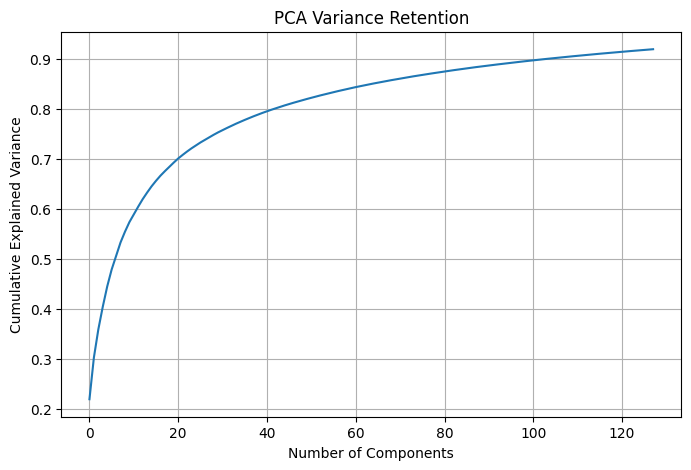

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "PCA Variance Retention"
)

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_05/8.png"
)

plt.show()

In [14]:
compressed_df = pd.DataFrame(
    compressed_embeddings
)

compressed_df.to_csv(
    "../Outputs/Notebook_05/compressed_embeddings.csv",
    index=False
)

print(
    compressed_df.shape
)

(14446, 128)


In [15]:
quantized_embeddings = (
    compressed_embeddings * 1000
).astype(np.int16)

print(
    quantized_embeddings.shape
)

print(
    quantized_embeddings.dtype
)

(14446, 128)
int16


In [16]:
quantized_df = pd.DataFrame(
    quantized_embeddings
)

quantized_df.to_csv(
    "../Outputs/Notebook_05/quantized_embeddings.csv",
    index=False
)

print(
    "Quantized embeddings saved"
)

Quantized embeddings saved


In [17]:
print(
    "Original Dimensions:",
    train_df.shape[1]
)

print(
    "Compressed Dimensions:",
    compressed_df.shape[1]
)

reduction = (
    1 -
    compressed_df.shape[1] /
    train_df.shape[1]
) * 100

print(
    "Dimension Reduction:",
    round(reduction,2),
    "%"
)

Original Dimensions: 512
Compressed Dimensions: 128
Dimension Reduction: 75.0 %


In [18]:
compressed_df.head(100).to_csv(
    "../Outputs/Notebook_05/sample_compressed_embeddings.csv",
    index=False
)

quantized_df.head(100).to_csv(
    "../Outputs/Notebook_05/sample_quantized_embeddings.csv",
    index=False
)